# Lab 04: The Scaling Relation That Depends on How You Fit It

**ASTR 457, Fall 2026, posted Thu Sep 24, due Wed Sep 30 by Noon (fork → PR, as always)**

**Extra credit, +5 points on this lab:** if you attended Charlotte Ward's Sep 22 Astronomy Colloquium, turn in at least a page of notes including two questions you had, as a text file in your `submissions/<netid>/` folder, by Noon Tue Sep 29.

*Why this lab: every scaling relation you will ever use ($M_{\rm BH}$–$\sigma$, Tully–Fisher, the mass–metallicity relation, the SN Ia standardization) was fit by someone who chose a regression method, and the choice changes the published slope. Knowing when ordinary least squares lies, by how much, and what to do instead is how you read those papers, and how you referee them.*

Every one of you has your own dataset: `data/<your netid>.csv`, a sample of dwarf
galaxies hosting active galactic nuclei, selected by their optical variability in the
style of Ward et al. (2022, arXiv:2110.13098). Dwarf-galaxy AGN are one of the few
windows we have on black holes in the $10^5$–$10^7\,M_\odot$ range, where the seeds of
supermassive black holes hide. Columns:

- `logMstar`, `err_logMstar`: $x = \log_{10}(M_*/M_\odot)$, the host stellar mass from
  SED fitting, and its $1\sigma$ uncertainty (0.2–0.4 dex; dwarf-galaxy photometry is hard),
- `logMBH`, `err_logMBH`: $y = \log_{10}(M_{\rm BH}/M_\odot)$, the virial black-hole
  mass from broad-line spectroscopy, and its $1\sigma$ uncertainty.

The relation you are after is

$$y = \alpha\,(x - 9.5) + \beta + \text{intrinsic scatter } \sigma_{\rm int},$$

pivoted at $M_* = 10^{9.5} M_\odot$ so $\alpha$ and $\beta$ don't fight each other. **Both
variables have measurement error, and the relation has real astrophysical scatter on top.**
I know your true $\alpha$, $\beta$, and $\sigma_{\rm int}$. You don't, your classmates'
values are different from yours, and so are your sample sizes.

**How this is graded.** Not on whether your code runs, but on whether your answers are
*right* and your uncertainties are *honest*. Part of your grade comes from how close your
reported $\alpha$ and $\beta$ are to your truth **in units of your own reported
uncertainty**. Tiny error bars you can't back up lose points; padded ones lose points too.
Calibration is the skill. The floor under "padded": your reported $\sigma_\alpha$ may not
exceed **3× the curvature uncertainty of your own generative fit** from Part 2 (if your
Hessian turns out singular, quote a profile-likelihood width instead and say so). Bigger
than that is not caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The fit everyone does first (15%)

Load your sample and plot it with error bars **on both axes**. Then fit the relation the
way most papers still do: **ordinary least squares** on $y$ vs $(x - 9.5)$, every point
weighted equally, errors ignored. Build the design matrix and solve the normal equations
yourself (lecture machinery, or `np.polyfit` if you must, but know what it's doing). Report
$\hat\alpha \pm \sigma$ using the standard OLS variance estimate, $s^2 (A^{\mathsf T}A)^{-1}$
with $s^2 = \mathrm{RSS}/(N-2)$ (residual-scaled; the errors play no role yet, on purpose).

Then answer, in a few sentences: which of OLS's assumptions does *your* dataset violate?
For the slope specifically, which way does the bias from the $x$-errors pull, and what
controls its size? (We named it in lecture on Sep 24. The effect is *supposed*
to be there; understanding exactly why, on your own data, is the point of this lab.)

In [21]:
from scipy.optimize import minimize
from scipy.stats import norm
from scipy.special import gamma
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import odr

data = pd.read_csv('../../labs/04/data/gracelh4.csv')
# data

/var/folders/51/t7p0d3qn31zbytwh8bdmcfk80000gn/T/ipykernel_5895/395293302.py:7: DeprecationWarning: `scipy.odr` is deprecated as of version 1.17.0 and will be removed in SciPy 1.19.0. Please use `https://pypi.org/project/odrpack/` instead.
  from scipy import odr


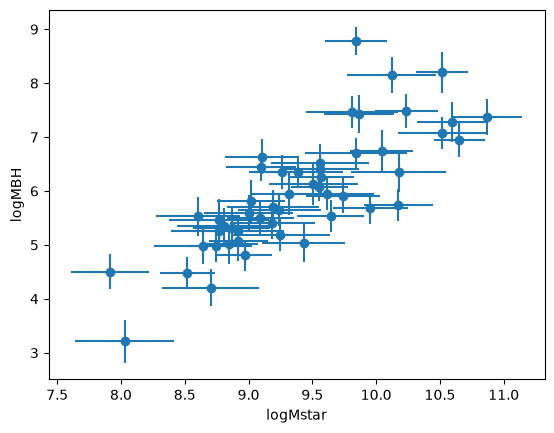

In [9]:
# Part 1: your work here

x = data['logMstar']
x_err = data['err_logMstar']

y = data['logMBH']
y_err = data['err_logMBH']

plt.errorbar(x, y, xerr = x_err, yerr = y_err, fmt = 'o')
plt.xlabel('logMstar')
plt.ylabel('logMBH')
plt.show()

In [15]:
# A_d = np.vstack([np.ones(N_demo), x_obs - 9.5]).T

A = np.vstack([x - 9.5, np.ones(len(x))]).T
AtA_inv = np.linalg.inv(A.T @ A)
theta = AtA_inv @ A.T @ y
beta = theta[1]
alpha = theta[0]

resid = y - A @ theta
s2 = (resid @ resid) / (len(y) - A.shape[1])
cov = s2 * AtA_inv

sigma_alpha = np.sqrt(cov[0, 0])

print("alpha =", alpha, "+/-", sigma_alpha)
print("beta =", beta)

alpha = 1.3018385101238055 +/- 0.13864094914490835
beta = 6.10985221163869


**ANSWER (a few sentences):**

OLS--> Assumes Gaussian noise, exact x, and independent points. 

Clearly, my dataset violates this, as it has errors in x (err_logMstar).

Those errors in x cause attenuation bias. Since the my found alpha is greater than zero, the attenuation bias makes it smaller than the true alpha, which means it gets pulled towards zero.

The bias is dependent on the home much bigger the measurement errors in x are as compared to the true spread in x. 

## Part 2: Estimators you can defend (40%)

Now fit the relation **three more ways** and compare:

1. **Weighted least squares** using the $y$-errors only:
   $\hat{\theta} = (A^{\mathsf T}\Sigma^{-1}A)^{-1}A^{\mathsf T}\Sigma^{-1}y$ with
   $\Sigma = \mathrm{diag}(\sigma_{y,i}^2)$, parameter covariance
   $(A^{\mathsf T}\Sigma^{-1}A)^{-1}$. Does weighting fix the Part 1 bias? Why or why not?

2. **Orthogonal distance regression** (`scipy.odr`, which warns that it is deprecated on
   import; that is fine in the course environment), which knows about the $x$-errors.
   Read what it minimizes before you run it. What does ODR assume about scatter
   *perpendicular to the relation*, and is that assumption true here?

3. **The generative model, honestly.** Write down where each data point comes from:
   the true stellar masses are drawn from the population,
   $x_i^{\rm true} \sim \mathcal{N}(\mu, \sigma_{\rm pop}^2)$; the relation plus intrinsic scatter
   makes the true BH mass; and your measurement errors corrupt both. Marginalizing over
   the (unobservable) true masses makes each observed pair $(x_i, y_i)$ a **bivariate
   Gaussian**:

   $$\begin{pmatrix} x_i \\ y_i \end{pmatrix} \sim \mathcal{N}\!\left[
   \begin{pmatrix} \mu \\ \alpha(\mu - 9.5) + \beta \end{pmatrix},\;
   \begin{pmatrix} \sigma_{\rm pop}^2 + \sigma_{x,i}^2 & \alpha\,\sigma_{\rm pop}^2 \\
   \alpha\,\sigma_{\rm pop}^2 & \alpha^2\sigma_{\rm pop}^2 + \sigma_{\rm int}^2 + \sigma_{y,i}^2 \end{pmatrix}
   \right]$$

   (Convince yourself of the three variance entries before you code; the off-diagonal
   covariance is what removes the attenuation bias. This is the Gaussian core of Kelly 2007, the paper behind
   every modern `linmix`-style fit.) Maximize the summed log-likelihood over all five
   parameters $(\alpha, \beta, \sigma_{\rm int}, \mu, \sigma_{\rm pop})$, and get uncertainties from
   the curvature of the log-likelihood at its peak (the observed information), and say so.

Make **one plot with all four fitted lines overplotted** on your data. They will not agree.
Explain, estimator by estimator, *why* each lands where it does, and which ingredient of the
data each one ignores.

Commit to a **final answer**: one $\alpha \pm \sigma$, $\beta \pm \sigma$, and
$\sigma_{\rm int} \pm \sigma$ you'd put in a paper, and justify the choice. Remember the
3× rule from the header.

In [25]:
#2a

# Taken from lecture
def gls(A, y, Sigma):
    Si = np.linalg.inv(Sigma)
    cov = np.linalg.inv(A.T @ Si @ A)
    return cov @ A.T @ Si @ y, cov

th_dw, cov_dw = gls(A, y, np.diag(y_err**2))

alpha_wls = th_dw[0]
beta_wls = th_dw[1]

sigma_alpha_wls = np.sqrt(cov_dw[0,0])
sigma_beta_wls = np.sqrt(cov_dw[1,1])

print('Least Weighted Squares')
print('alpha wls: ', alpha_wls, ' +- ', sigma_alpha_wls)
print('beta wls: ', beta_wls, ' +- ', sigma_beta_wls)


# Since the attenuation bias is derived from the measurement
# errors in x, the WLS method does not fix it.

Least Weighted Squares
alpha wls:  1.2927925993527014  +-  0.07123644425180152
beta wls:  6.126394395889556  +-  0.04501562120864741


In [24]:
#2b

def _line(B, x):
    return B[0] * (x - 9.5) + B[1]

_odr = odr.ODR(odr.RealData(x, y, sx=x_err, sy=y_err), odr.Model(_line), beta0=[1.0, 6.3])
odr_out = _odr.run()
alpha_odr, beta_odr = odr_out.beta
sig_alpha_odr = odr_out.sd_beta[0]

print("alpha ODR:", alpha_odr, "+/-", sig_alpha_odr)
print("beta ODR:", beta_odr)

# This method does take into account the x errors. However, it assumes that there is
# no intrinsic scatter. In the beginning, the lab states that there is an astrophysical
# scatter on top, so this cannot be the method that works. 

alpha ODR: 1.8046800264844904 +/- 0.17874797565779874
beta ODR: 6.1464876507834365


In [27]:
def neg2logL_gen(p, x=x, y=y, sx=x_err, sy=y_err):
    alpha, beta, log_sint, mu, log_sig_pop = p
    sint2 = np.exp(2 * log_sint)
    tau2 = np.exp(2 * log_sig_pop)
    dx = x - mu
    dy = y - (alpha * (mu - 9.5) + beta)
    s11 = tau2 + sx**2
    s22 = alpha**2 * tau2 + sint2 + sy**2
    s12 = alpha * tau2
    det = s11 * s22 - s12**2
    quad = (s22 * dx**2 - 2 * s12 * dx * dy + s11 * dy**2) / det
    return np.sum(np.log(det) + quad)

_start = [alpha, beta, np.log(0.3), x.mean(), np.log(x.std())]

res_gen = minimize(neg2logL_gen, _start, method='Nelder-Mead', options=dict(xatol=1e-8, fatol=1e-8, maxiter=20000))

p_gen = res_gen.x
# print(p_gen)

def numerical_hessian(f, p, h=1e-4):
    p = np.asarray(p, float)
    n = p.size
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            e_i = np.zeros(n)
            e_j = np.zeros(n)
            e_i[i] = h
            e_j[j] = h
            H[i, j] = (
                f(p + e_i + e_j)
                - f(p + e_i - e_j)
                - f(p - e_i + e_j)
                + f(p - e_i - e_j)) / (4 * h * h)
    return H


cov_gen = 2 * np.linalg.inv(numerical_hessian(neg2logL_gen, p_gen))

sigma_alpha_gen = np.sqrt(cov_gen[0, 0])
sigma_beta_gen = np.sqrt(cov_gen[1, 1])

sigma_log_sint = np.sqrt(cov_gen[2, 2])
sigma_int_gen = np.exp(p_gen[2])
sigma_sigma_int_gen = sigma_int_gen * sigma_log_sint
alpha_gen = p_gen[0]
beta_gen = p_gen[1]
sigma_int_gen = np.exp(p_gen[2])

print("alpha =", alpha_gen, "+/-", sigma_alpha_gen)
print("beta =", beta_gen, "+/-", sigma_beta_gen)
print("sigma_int =", sigma_int_gen, "+/-", sigma_sigma_int_gen)

alpha = 1.5488246861120865 +/- 0.1870903026160491
beta = 6.123509078943023 +/- 0.1006839183969757
sigma_int = 0.43291973980944665 +/- 0.10593055301570155


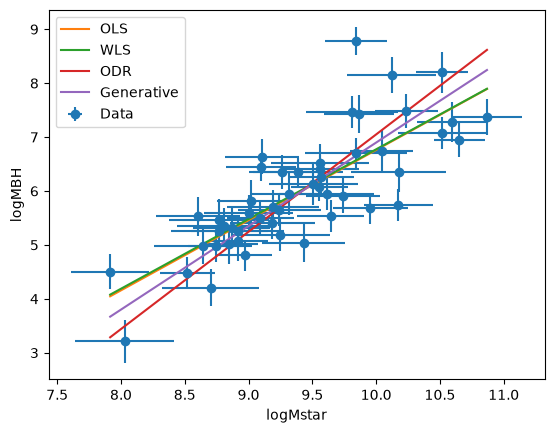

In [29]:
# Plot all four fitted lines

xx = np.linspace(x.min(), x.max(), 200)

plt.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='o',label='Data')

# OLS
plt.plot(xx, alpha * (xx - 9.5) + beta, label='OLS')

# WLS
plt.plot(xx, alpha_wls * (xx - 9.5) + beta_wls, label='WLS')

# ODR
plt.plot(xx, alpha_odr * (xx - 9.5) + beta_odr,label='ODR')

# Generative model
plt.plot(xx, alpha_gen * (xx - 9.5) + beta_gen, label='Generative')

plt.xlabel('logMstar')
plt.ylabel('logMBH')
plt.legend()
plt.show()

In [ ]:
#OLS: alpha = 1.3018 +/- 0.13864

# OLS treats all points equally (outliers included) and does not take into account errors
# in both the x and y. Since it does not take into account x errors, there is an attenuation
# bias that pulls the slope towards zero. 


#WLS: alpha = 1.2927  +-  0.071236

# While WLS takes into account the y errors, and weighs points with smaller errors more than
# ones with more significant error, it does not take into account the x errors. This causes
# the line ot be quite similar to the OLS line.

#ODR: alpha = 1.8046 +/- 0.1787

# This accounts for errors in both x and y, resulting in a steeper slope. However, this does
# not include instrinsic scatter. That means this is not true to the dataset.

#Generative: alpha = 1.5488 +/- 0.18709

# This takes into account the instrinsic scatter, and the x and y measurement errors. For
# that reason, it sits between the ODR and the WLS/OLS lines. 



**FINAL ANSWER:** $\alpha = $ 1.5488 $\pm$ 0.187 , $\beta = $ 6.1235 $\pm$ 0.1006 , $\sigma_{\rm int} = $ 0.4329 $\pm$ 0.1059 dex

**Justification and uncertainty method (a short paragraph):**

I chose the Generative Model. Out of the four models presented, it was the only one that took both measurement errors in x and y into account, as well as the astrophysical scatter stated in the beginning of the lab. This is the model that removes the attenuation bias the best out of the four. 

## Part 3: The verification plan, written first and then executed (35%)

**Before you run anything below, write the plan** (3a). A verification plan you invent
after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the generative recipe in
   Part 2 tells you exactly how) and confirm your fit recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot each estimator's bias and variance for $\alpha$. This is
   *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time, for all three reported parameters?
4. **Sensitivity**: what happens to $\hat\alpha$ if the catalog $x$-errors are wrong by
   ±50% (generate correctly, fit with the mis-stated errors)? If the true population isn't Gaussian (try drawing $x^{\rm true}$ from a uniform
   distribution with the same mean and variance instead)? If you had assumed $\sigma_{\rm int} = 0$?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

*your plan goes here*

Closure: I will simulate a dataset with chosen values of alpha, beta, sigma_int, u and sigma_pop. With this simulated dataset, I can apply it to the generative model in part 2 to see if the recovered parameters are consistent. Failure would be if the generative model does not recover the input parameters. 

Bias & Efficency: I will Monte Carlo simulations for each method. For each one, I will compare the fitted alpha to the true alpha, and compare the variances to see which one is more efficent. Failure would look like significant bias between the true and fitted alphas. 

Coverage: I will check across many simulaitons to see if the true values of alpha, beta and sigma_int are within 68% confidence interval. Failure would look like the true values falling outside of that more or less than 68%. 

Sensitivity: I will shift the x-errors from -50% to 50%. This should result in a shift in alpha values, and that difference between the two should be similar. I will change the x_true population from a Gaussian to a uniform with the same variance and mean, with the assumption that sigma_int = 0. Failure would be no shift in alpha. 

In [ ]:
# Part 3b: execute the plan here

In [42]:
# Truth values: use the best-fit generative values from Part 2
truth = {
    'alpha': alpha_gen,
    'beta': beta_gen,
    'sig_int': sigma_int_gen,
    'mu': p_gen[3],
    'sig_pop': np.exp(p_gen[4])}

N = len(x)
sx = np.asarray(x_err)
sy = np.asarray(y_err)

def simulate_data(rng, x_population='gaussian'):
    if x_population == 'gaussian':
        x_true = rng.normal(truth['mu'],truth['sig_pop'],N)
    elif x_population == 'uniform':
        # Uniform distribution with same mean and variance
        half_width = np.sqrt(3) * truth['sig_pop']
        x_true = rng.uniform(
            truth['mu'] - half_width,
            truth['mu'] + half_width,N)
    y_true = (
        truth['alpha'] * (x_true - 9.5)
        + truth['beta']
        + rng.normal(0, truth['sig_int'], N))
    x_obs = x_true + rng.normal(0, sx)
    y_obs = y_true + rng.normal(0, sy)
    return x_obs, y_obs


def fit_ols(xd, yd):
    A_sim = np.vstack([xd - 9.5, np.ones(len(xd))]).T
    AtA_inv = np.linalg.inv(A_sim.T @ A_sim)
    theta = AtA_inv @ A_sim.T @ yd
    resid = yd - A_sim @ theta
    s2 = (resid @ resid) / (len(yd) - 2)
    cov = s2 * AtA_inv
    return theta[0], theta[1], np.sqrt(cov[0, 0])


def fit_wls(xd, yd, syd):
    A_sim = np.vstack([xd - 9.5, np.ones(len(xd))]).T
    theta, cov = gls(A_sim,yd,np.diag(syd**2))
    return theta[0], theta[1], np.sqrt(cov[0, 0])


def fit_odr(xd, yd, sxd, syd):
    def line(B, x):
        return B[0] * (x - 9.5) + B[1]
    fit = odr.ODR(
        odr.RealData(xd, yd, sx=sxd, sy=syd),
        odr.Model(line),
        beta0=[truth['alpha'], truth['beta']])
    out = fit.run()
    return out.beta[0], out.beta[1], out.sd_beta[0]


def fit_gen(xd, yd, sxd, syd, get_cov=True):

    def n2ll(p):
        alpha, beta, log_sint, mu, log_sig_pop = p

        sint2 = np.exp(2 * log_sint)
        tau2 = np.exp(2 * log_sig_pop)

        dx = xd - mu
        dy = yd - (alpha * (mu - 9.5) + beta)

        s11 = tau2 + sxd**2
        s22 = alpha**2 * tau2 + sint2 + syd**2
        s12 = alpha * tau2

        det = s11 * s22 - s12**2

        quad = (
            s22 * dx**2
            - 2 * s12 * dx * dy
            + s11 * dy**2
        ) / det

        return np.sum(np.log(det) + quad)

    start = [
        truth['alpha'],
        truth['beta'],
        np.log(truth['sig_int']),
        np.mean(xd),
        np.log(np.std(xd))
    ]

    res = minimize(
        n2ll,
        start,
        method='Nelder-Mead',
        options=dict(
            xatol=1e-8,
            fatol=1e-8,
            maxiter=20000
        )
    )

    p = res.x

    alpha_fit = p[0]
    beta_fit = p[1]
    sint_fit = np.exp(p[2])

    # For simulations where we only need the fitted values
    if not get_cov:
        return alpha_fit, beta_fit, sint_fit

    # Only calculate Hessian when uncertainties are needed
    # Only calculate Hessian when uncertainties are needed
    H = numerical_hessian(n2ll, p)
    
    try:
        cov = 2 * np.linalg.inv(H)
    except np.linalg.LinAlgError:
        return (
            alpha_fit,
            beta_fit,
            sint_fit,
            np.nan,
            np.nan,
            np.nan
        )
    
    # Check that the variances are usable
    diag = np.diag(cov)
    
    if (not np.all(np.isfinite(diag))) or np.any(diag <= 0):
        return (
            alpha_fit,
            beta_fit,
            sint_fit,
            np.nan,
            np.nan,
            np.nan
        )
    
    sig_alpha = np.sqrt(cov[0, 0])
    sig_beta = np.sqrt(cov[1, 1])
    sig_sint = sint_fit * np.sqrt(cov[2, 2])
    
    return (
        alpha_fit,
        beta_fit,
        sint_fit,
        sig_alpha,
        sig_beta,
        sig_sint
    )

In [43]:
# CLOSURE

rng = np.random.default_rng(42)

x_sim, y_sim = simulate_data(rng)

(
    alpha_fit,
    beta_fit,
    sint_fit,
    sig_alpha,
    sig_beta,
    sig_sint
) = fit_gen(x_sim, y_sim, sx, sy)

print("TRUE vs RECOVERED")
print()

print(
    "alpha:",
    truth['alpha'],
    "   recovered:",
    alpha_fit,
    "+/-",
    sig_alpha)

print(
    "beta:",
    truth['beta'],
    "   recovered:",
    beta_fit,
    "+/-",
    sig_beta)

print(
    "sigma_int:",
    truth['sig_int'],
    "   recovered:",
    sint_fit,
    "+/-",
    sig_sint)

TRUE vs RECOVERED

alpha: 1.5488246861120865    recovered: 1.780490128741616 +/- 0.31809397353801244
beta: 6.123509078943023    recovered: 6.159922339432724 +/- 0.09769960930865905
sigma_int: 0.43291973980944665    recovered: 0.2859401027689434 +/- 0.16185230459993669


Bias:
OLS -0.32989555533547565
WLS -0.32830946437129627
ODR 0.25251903390416497
Generative 0.03087310670618071

Variance:
OLS 0.02251030834099383
WLS 0.02261362998183411
ODR 0.05968374429138764
Generative 0.04729495522450871


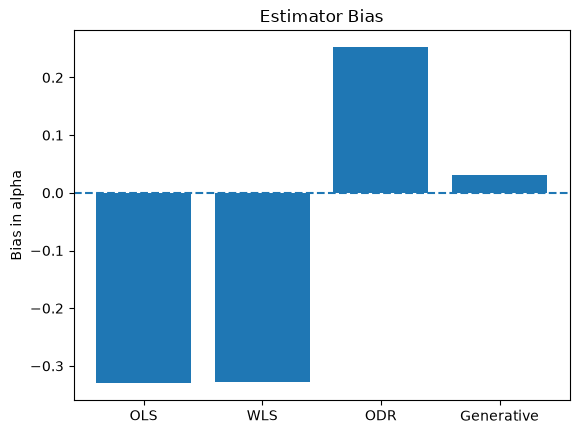

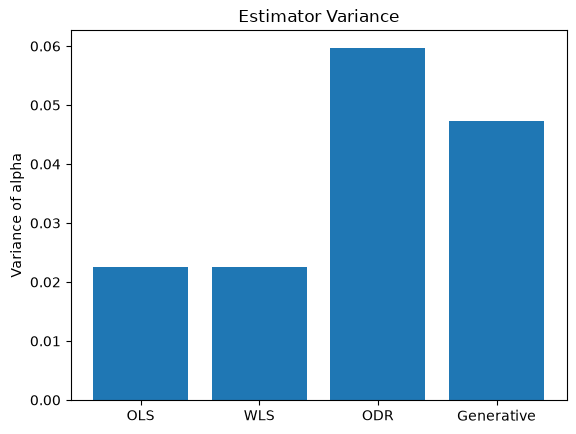

In [44]:
# BIAS AND EFFICIENCY

n_sims = 300

alpha_ols_mc = []
alpha_wls_mc = []
alpha_odr_mc = []
alpha_gen_mc = []

for seed in range(n_sims):
    
    rng = np.random.default_rng(seed)
    
    x_sim, y_sim = simulate_data(rng)
    
    # OLS
    ao, _, _ = fit_ols(x_sim, y_sim)
    alpha_ols_mc.append(ao)
    
    # WLS
    aw, _, _ = fit_wls(x_sim, y_sim, sy)
    alpha_wls_mc.append(aw)
    
    # ODR
    ad, _, _ = fit_odr(x_sim, y_sim, sx, sy)
    alpha_odr_mc.append(ad)
    
    # Generative
    ag, _, _ = fit_gen(
    x_sim, y_sim, sx, sy,
    get_cov=False
)
    alpha_gen_mc.append(ag)


alpha_ols_mc = np.array(alpha_ols_mc)
alpha_wls_mc = np.array(alpha_wls_mc)
alpha_odr_mc = np.array(alpha_odr_mc)
alpha_gen_mc = np.array(alpha_gen_mc)


names = ['OLS', 'WLS', 'ODR', 'Generative']

estimates = [
    alpha_ols_mc,
    alpha_wls_mc,
    alpha_odr_mc,
    alpha_gen_mc
]

biases = [
    np.mean(a) - truth['alpha']
    for a in estimates
]

variances = [
    np.var(a, ddof=1)
    for a in estimates
]


print("Bias:")
for name, bias in zip(names, biases):
    print(name, bias)

print()
print("Variance:")
for name, var in zip(names, variances):
    print(name, var)

plt.figure()

plt.bar(names, biases)
plt.axhline(0, linestyle='--')

plt.ylabel('Bias in alpha')
plt.title('Estimator Bias')

plt.show()


plt.figure()

plt.bar(names, variances)

plt.ylabel('Variance of alpha')
plt.title('Estimator Variance')

plt.show()

In [45]:
# COVERAGE

n_sims = 200

cover_alpha = []
cover_beta = []
cover_sint = []

failed_hessian = 0

for seed in range(n_sims):

    rng = np.random.default_rng(seed + 1000)

    x_sim, y_sim = simulate_data(rng)

    (
        a,
        b,
        sint,
        sa,
        sb,
        ssint
    ) = fit_gen(x_sim, y_sim, sx, sy)

    # Skip simulations where the curvature uncertainty failed
    if not np.all(np.isfinite([sa, sb, ssint])):
        failed_hessian += 1
        continue

    cover_alpha.append(
        (a - sa <= truth['alpha']) and
        (truth['alpha'] <= a + sa)
    )

    cover_beta.append(
        (b - sb <= truth['beta']) and
        (truth['beta'] <= b + sb)
    )

    cover_sint.append(
        (sint - ssint <= truth['sig_int']) and
        (truth['sig_int'] <= sint + ssint)
    )


print("Successful intervals:", len(cover_alpha))
print("Failed Hessians:", failed_hessian)
print()

print("68% Coverage")
print("alpha:", np.mean(cover_alpha))
print("beta:", np.mean(cover_beta))
print("sigma_int:", np.mean(cover_sint))

Successful intervals: 195
Failed Hessians: 5

68% Coverage
alpha: 0.6820512820512821
beta: 0.6615384615384615
sigma_int: 0.7538461538461538


In [48]:
# =========================================
# SENSITIVITY CHECKS
# =========================================

n_sims = 100


# -----------------------------------------
# 1. X-ERRORS WRONG BY -50% AND +50%
# -----------------------------------------

alpha_lowerr = []
alpha_correct = []
alpha_higherr = []

for seed in range(n_sims):

    rng = np.random.default_rng(seed + 2000)

    # Generate with the CORRECT errors
    x_sim, y_sim = simulate_data(rng)

    # Fit assuming x-errors are 50% too small
    a_low, _, _ = fit_gen(
        x_sim,
        y_sim,
        0.5 * sx,
        sy,
        get_cov=False
    )

    # Fit using correct x-errors
    a_correct, _, _ = fit_gen(
        x_sim,
        y_sim,
        sx,
        sy,
        get_cov=False
    )

    # Fit assuming x-errors are 50% too large
    a_high, _, _ = fit_gen(
        x_sim,
        y_sim,
        1.5 * sx,
        sy,
        get_cov=False
    )

    alpha_lowerr.append(a_low)
    alpha_correct.append(a_correct)
    alpha_higherr.append(a_high)


print("X-ERROR SENSITIVITY")
print("True alpha:", truth['alpha'])
print("-50% x errors:", np.mean(alpha_lowerr))
print("Correct x errors:", np.mean(alpha_correct))
print("+50% x errors:", np.mean(alpha_higherr))
print()


# -----------------------------------------
# 2. UNIFORM x_true POPULATION
# -----------------------------------------

alpha_uniform = []

for seed in range(n_sims):

    rng = np.random.default_rng(seed + 3000)

    # Generate x_true from a uniform population
    # with the same mean and variance
    x_sim, y_sim = simulate_data(
        rng,
        x_population='uniform'
    )

    # Fit using the normal Gaussian-population model
    a, _, _ = fit_gen(
        x_sim,
        y_sim,
        sx,
        sy,
        get_cov=False
    )

    alpha_uniform.append(a)


alpha_uniform = np.array(alpha_uniform)

print("UNIFORM x_true SENSITIVITY")
print("True alpha:", truth['alpha'])
print("Mean alpha with uniform x_true:", np.mean(alpha_uniform))
print(
    "Shift:",
    np.mean(alpha_uniform) - truth['alpha']
)
print()


# -----------------------------------------
# 3. ASSUME sigma_int = 0
# -----------------------------------------

def fit_gen_no_scatter(xd, yd, sxd, syd):

    def n2ll(p):

        alpha, beta, mu, log_sig_pop = p

        tau2 = np.exp(2 * log_sig_pop)

        dx = xd - mu
        dy = yd - (alpha * (mu - 9.5) + beta)

        s11 = tau2 + sxd**2

        # Intrinsic scatter is forced to zero here
        s22 = alpha**2 * tau2 + syd**2

        s12 = alpha * tau2

        det = s11 * s22 - s12**2

        quad = (
            s22 * dx**2
            - 2 * s12 * dx * dy
            + s11 * dy**2
        ) / det

        return np.sum(np.log(det) + quad)

    start = [
        truth['alpha'],
        truth['beta'],
        np.mean(xd),
        np.log(np.std(xd))
    ]

    res = minimize(
        n2ll,
        start,
        method='Nelder-Mead',
        options=dict(
            xatol=1e-8,
            fatol=1e-8,
            maxiter=20000
        )
    )

    return res.x[0]


alpha_no_scatter = []

for seed in range(n_sims):

    rng = np.random.default_rng(seed + 4000)

    # Generate data WITH the true intrinsic scatter
    x_sim, y_sim = simulate_data(rng)

    # Fit while incorrectly assuming sigma_int = 0
    a = fit_gen_no_scatter(
        x_sim,
        y_sim,
        sx,
        sy)

    alpha_no_scatter.append(a)


alpha_no_scatter = np.array(alpha_no_scatter)

print("NO INTRINSIC SCATTER SENSITIVITY")
print("True alpha:", truth['alpha'])
print(
    "Mean alpha assuming sigma_int = 0:",
    np.mean(alpha_no_scatter)
)
print(
    "Shift:",
    np.mean(alpha_no_scatter) - truth['alpha']
)

X-ERROR SENSITIVITY
True alpha: 1.5488246861120865
-50% x errors: 1.2872981683398566
Correct x errors: 1.5478055856343758
+50% x errors: 1.884252224116749

UNIFORM x_true SENSITIVITY
True alpha: 1.5488246861120865
Mean alpha with uniform x_true: 1.5355780432492423
Shift: -0.01324664286284416

NO INTRINSIC SCATTER SENSITIVITY
True alpha: 1.5488246861120865
Mean alpha assuming sigma_int = 0: 1.8162121048629336
Shift: 0.26738741875084715


**WHAT THE CHECKS FOUND:**

Closure Check: all values fell within 1 sigma. That passes the check. 

Bias & Efficency: The OLS & WLS are quite biased, the ODR somewhat biased, and the Generateive method has the smallest amount of bias. That is to be expected. 

Coverage: Very similar to 68%, but sigma_int is a bit higher. 


Sensitivity: The wrong x-errors caused shifts in alpha as expected, so very sensitive to this. The recovered slope is quite similar to the true value, indicating small insenitivity to this. Assuming sigma_int = 0 caused a rise in error, biasing the slope upwards, indicating a high sensitivity. 

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true.

**AI-USE APPENDIX:**

*your answer goes here*

I used ChatGPT.

I sent it the entire lab at the beginning so I could ask questions about specific sections without having to copy and paste text over and over.

Part 1:

What is B?

How can I plot it without knowing what B is?

Gave Chat Lecture from the 24th

Asked about the design equation. Asked about machinery in lab. 
Asked Chat to visually show me with formulas what the lab was doing.
Followed that structure. 
Chat provided boilerplate code for the design matrix.

Chat provided the boiler plate code the OLS uncertainty


Part 2:

a)
I asked about the formulas in the question, and Chat pointed out that the lecture code was exactly what I needed to answer this question. 

Asked if what i put down was good for this--yes.

b) 


What is the import?

I found the function that matched in the lecture and double checked with Chat that I was looking at the right thing. In Chat's response, it gave me the print statements which I copied over here. 


c)

I found the function from lab I wanted to use to answer question 3, and I asked
Chat to update it to my variables.

I asked Chat to give me the code for setting the starting values and for running minimize.
I asked for the boilerplate code for doing the numerical hessian, as well as the uncertainty extraction and print statements.


d)

Requested the boiler-plate code to plot all of the lines.

Reviewed what each method did with Chat. 



3)
Requested the boilerplate code for my check plan. 
Asked to debug an error in Coverage.

Discussed results of 